 # Movie Review Sentiment Analysis
 ## 65070501050 | Wongsatorn Sungsilapawech

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv('IMDB Dataset.csv')

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
df_pos = df[df['sentiment'] == 'positive']
print(df_pos)

df_neg = df[df['sentiment'] == 'negative']
print(df_neg)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
4      Petter Mattei's "Love in the Time of Money" is...  positive
5      Probably my all-time favorite movie, a story o...  positive
...                                                  ...       ...
49983  I loved it, having been a fan of the original ...  positive
49985  Imaginary Heroes is clearly the best film of t...  positive
49989  I got this one a few weeks ago and love it! It...  positive
49992  John Garfield plays a Marine who is blinded by...  positive
49995  I thought this movie did a down right good job...  positive

[25000 rows x 2 columns]
                                                  review sentiment
3      Basically there's a family where a little boy ...  negative
7      This show was an amazing, fre

> **NOTE** I tried to sample for 5000 samples, but the model is too perfect (100% accuracy and 100% validation accuracy) due to small dataset and complex deep learning model, so I increased the number of samples into 25000

In [124]:
df_pos_sample = df_pos.sample(frac=0.5)
df_neg_sample = df_neg.sample(frac=0.5)

print(df_pos_sample)
print(df_neg_sample)

                                                  review sentiment
41950  Parker (Johnathan Schaech) is an aspiring writ...  positive
29129  This jingoist outing concerns the usual battle...  positive
7828   "Imagine if you could bring things back to lif...  positive
37945  This brings back so many childhood memories. (...  positive
39821  Recently was traveling in Norway from Bergen, ...  positive
...                                                  ...       ...
40173  Police Story is arguably one of the best works...  positive
15625  OhMyGAWD!!! THE MAGIC GARDEN is perhaps one of...  positive
42470  "Where to begin, where to begin . . ?(Savannah...  positive
46699  I found the memorable quotes searching for vid...  positive
35585  Ti%s and As*, lots of boobies. Some great char...  positive

[12500 rows x 2 columns]
                                                  review sentiment
14262  Hobgoblins....Hobgoblins....where do I begin?!...  negative
46054  Unfortunately I think this is

In [125]:
df_sample = pd.concat([df_pos_sample, df_neg_sample], ignore_index=True)
df_sample.head(10)

,review,sentiment
0,Parker (Johnathan Schaech) is an aspiring writ...,positive
1,This jingoist outing concerns the usual battle...,positive
2,"""Imagine if you could bring things back to lif...",positive
3,This brings back so many childhood memories. (...,positive
4,"Recently was traveling in Norway from Bergen, ...",positive
5,I remember watching Police Squad! when it firs...,positive
6,i L-O-V-E this movie... everyone and their gra...,positive
7,This movie was highly entertaining. The soundt...,positive
8,This is one of my favorite Govinda movies of a...,positive
9,A tremendous action movie that I have ever see...,positive


# Clean the text

In [126]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [127]:
from nltk.corpus import stopwords
stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [128]:
import re

REPLACE_BY_SPLACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

In [129]:
def clean_text(text):
  text = text.lower()
  text = REPLACE_BY_SPLACE_RE.sub(' ', text)
  text = BAD_SYMBOLS_RE.sub('', text)
  text = text.replace('x', '')
  text = ' '.join(word for word in text.split() if word not in STOPWORDS)
  return text

In [130]:
df_sample['review'] = df_sample['review'].apply(clean_text)

df_sample['review'] = df_sample['review'].str.replace('\d+','')

# Modelling

## Train the tokenizer

In [131]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_NB_WORDS = 50000

MAX_SEQUENCE_LENGTH = 250

EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words = MAX_NB_WORDS,
                      filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~',
                      lower=True)
tokenizer.fit_on_texts(df_sample['review'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.'%len(word_index))

Found 114122 unique tokens.


## Pad the sequence

In [132]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = tokenizer.texts_to_sequences(df_sample['review'].values)
X = pad_sequences(X, maxlen = MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (25000, 250)


In [133]:
df_sample['review'].values[0]

'parker johnathan schaech aspiring writer still looking big break meantime works telephone adviser manhattan psychic hotline one day unfortunately apartment building burns parker cat make alive stuck arduous task finding affordable housing big apple word comes parker lady samantha alison eastwood searching roommate accept gay male since parker straight price right decides pretend gay samantha likes start welcomes new cohabitant poor parker sam lovely intelligent desirable able keep true nature control besides doesnt sam successful businessmanboyfriend anyway sweet likable humorous film two attractive stars eastwood schaech naturally plot string keep ruse scenes sam asking parker shampoo showering pleading hold bed receives bad news also necessary parker produce fake gay mate boris sam insists upon fiing man knows hopefully gay community find offensive viewer thought issues treated sensitivity subtlety small scale movie costumes sets camera work quite nice also therefore love funny tale

In [134]:
X[0]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,  2232, 25900, 13819,  6443,   500,
          46,   171,    99,   972,  6231,   391,  7363, 14889,  3932,
        4609, 31726,     4,   166,   370,  1424,  1248,  2893,  2232,
         991,    23,

## Convert output label into numeric format

In [135]:
Y = pd.get_dummies(df_sample['sentiment']).values
print('Shape of label tensor:', Y.shape)

Shape of label tensor: (25000, 2)


In [136]:
Y

array([[False,  True],
       [False,  True],
       [False,  True],
       ...,
       [ True, False],
       [ True, False],
       [ True, False]])

## Split dataset to Training and Test set

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(17500, 250) (17500, 2)
(7500, 250) (7500, 2)


## Construct LSTM Text Classifier

In [141]:
from keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, GlobalAveragePooling1D
from keras.callbacks import EarlyStopping


model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length = X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(2, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# model = Sequential()
# model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
# model.add(GlobalAveragePooling1D())        
# model.add(Dense(32, activation='relu'))
# model.add(Dense(2, activation='softmax'))    # for one-hot labels with 2 classes
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [142]:
epochs=20
batch_size=128

history = model.fit(X_train, Y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.3,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=6, min_delta=0.0001)])

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0.7463 - loss: 0.5010 - val_accuracy: 0.8377 - val_loss: 0.3700
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.9167 - loss: 0.2247 - val_accuracy: 0.8636 - val_loss: 0.3284
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9544 - loss: 0.1349 - val_accuracy: 0.8600 - val_loss: 0.4732
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 279ms/step - accuracy: 0.9798 - loss: 0.0684 - val_accuracy: 0.8381 - val_loss: 0.5318
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 279ms/step - accuracy: 0.9891 - loss: 0.0374 - val_accuracy: 0.8526 - val_loss: 0.6062
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 273ms/step - accuracy: 0.9926 - loss: 0.0251 - val_accuracy: 0.8345 - val_loss: 0.6409
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 295ms/step - accuracy: 0.9939 - loss: 0.0221 - val_accuracy: 0.8469 - val_loss: 0.7283
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - accuracy: 0.9915 - loss: 0.0261 - val_accu

## Evaluate the model

In [121]:
acc = model.evaluate(X_test, Y_test)
print('Test set \n\tLoss: {:0.3f}\n\tAccuracy: {:0.3f}'.format(acc[0], acc[1]))

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8040 - loss: 0.6338
Test set 
	Loss: 0.634
	Accuracy: 0.804


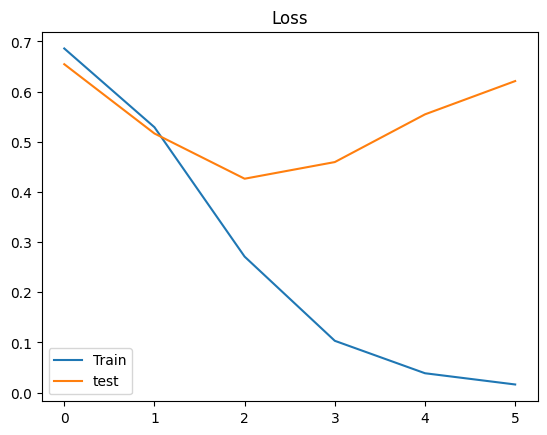

In [122]:
plt.title('Loss')
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

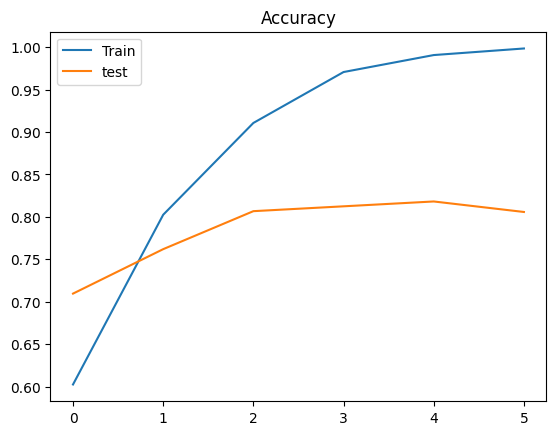

In [123]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [144]:
labels = pd.get_dummies(df_sample['sentiment']).columns
list(labels)

['negative', 'positive']

In [145]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

all_ids = np.arange(len(labels))

cm = confusion_matrix(Y_test.argmax(axis=1), y_pred.argmax(axis=1), labels = all_ids)
pd.DataFrame(cm,index=labels, columns=labels)

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step


,negative,positive
negative,3223,525
positive,611,3141


In [156]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_true=Y_test.argmax(axis=1),
                            y_pred=y_pred.argmax(axis=1)))

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      3748
           1       0.86      0.84      0.85      3752

    accuracy                           0.85      7500
   macro avg       0.85      0.85      0.85      7500
weighted avg       0.85      0.85      0.85      7500



> **Observation** From the accuracy graph, it seems like the model is quite overfitted. But looking at the report, it seems like the model works fine (observing well precision and recall)

> I tried to test the new text:
>  * This is quite a bit interesting
>  * This is quite a bit uninteresting
>  * This gets my heart

In [151]:
import numpy as np
new_complaint = ['This is quite a bit interesting']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
labels=pd.get_dummies(df_sample['sentiment']).columns.values
print(pred, labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.08793221 0.9120677 ]] positive


In [154]:
new_complaint = ['This is quite a bit uninteresting']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
labels=pd.get_dummies(df_sample['sentiment']).columns.values
print(pred, labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.6084226  0.39157745]] negative


In [155]:
new_complaint = ['This get my heart']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
labels=pd.get_dummies(df_sample['sentiment']).columns.values
print(pred, labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[0.29102746 0.7089726 ]] positive


> All of them predicted well